# Restoration and Enhancement of Degraded Images Using Digital Image Processing

### Digital Image Processing Mini Project

**Objective:**  
To restore degraded images using digital image processing techniques and compare different restoration methods based on visual quality and quantitative evaluation metrics.

### Techniques Used
- Gaussian Noise
- Median Filtering
- Gaussian Filtering
- Contrast Enhancement
- MSE
- PSNR
- SSIM

## 1. Introduction

Digital images can be affected by noise and other forms of degradation during image capture, transmission, storage, or processing. Such degradation can reduce image quality and make important details difficult to identify.

Image restoration is the process of improving a degraded image and recovering its quality using suitable image processing techniques.

In this project, clean images are artificially degraded by adding Gaussian noise. Different restoration techniques such as Median Filtering, Gaussian Filtering, and Contrast Enhancement are then applied. The restored images are compared with the original images using visual analysis and quantitative metrics.

## 2. Problem Statement

The objective of this project is to restore images that have been degraded by noise.

A clean image is first taken as the reference image. Gaussian noise is then added to simulate degradation. Different image restoration techniques are applied to reduce the noise and improve the image quality.

The performance of the restoration techniques is evaluated using Mean Squared Error (MSE), Peak Signal-to-Noise Ratio (PSNR), and Structural Similarity Index (SSIM).

## 3. Objectives

The main objectives of this project are:

1. To understand image degradation caused by noise.
2. To simulate Gaussian noise on input images.
3. To restore degraded images using Median Filtering.
4. To restore degraded images using Gaussian Filtering.
5. To improve the visual quality using contrast enhancement.
6. To compare the performance of different restoration techniques.
7. To evaluate the restored images using MSE, PSNR, and SSIM.

In [1]:
# Import required libraries

import cv2
import numpy as np
import matplotlib.pyplot as plt

from skimage.metrics import structural_similarity as ssim

from google.colab import files

print("Libraries imported successfully!")

Libraries imported successfully!


## 4. Image Upload

Four sample images are used in this project as the original reference images.

The images are uploaded directly to Google Colab and resized to a common resolution so that they can be processed consistently.

In [2]:
# Upload images

uploaded = files.upload()

print("Images uploaded successfully!")
print("Number of images:", len(uploaded))

Saving img 4.jpeg to img 4.jpeg
Saving img 3.jpeg to img 3.jpeg
Saving img 2.jpg to img 2.jpg
Saving img 1.jpeg to img 1.jpeg
Images uploaded successfully!
Number of images: 4


In [3]:
# Read and resize the uploaded images

images = []

for name in uploaded.keys():
    img = cv2.imread(name)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (512, 512))
    images.append(img)

print("Number of images loaded:", len(images))

Number of images loaded: 4


## 5. Original Images

The uploaded images are displayed below before applying any degradation or restoration technique. These images are treated as the reference images for evaluating the restoration methods.

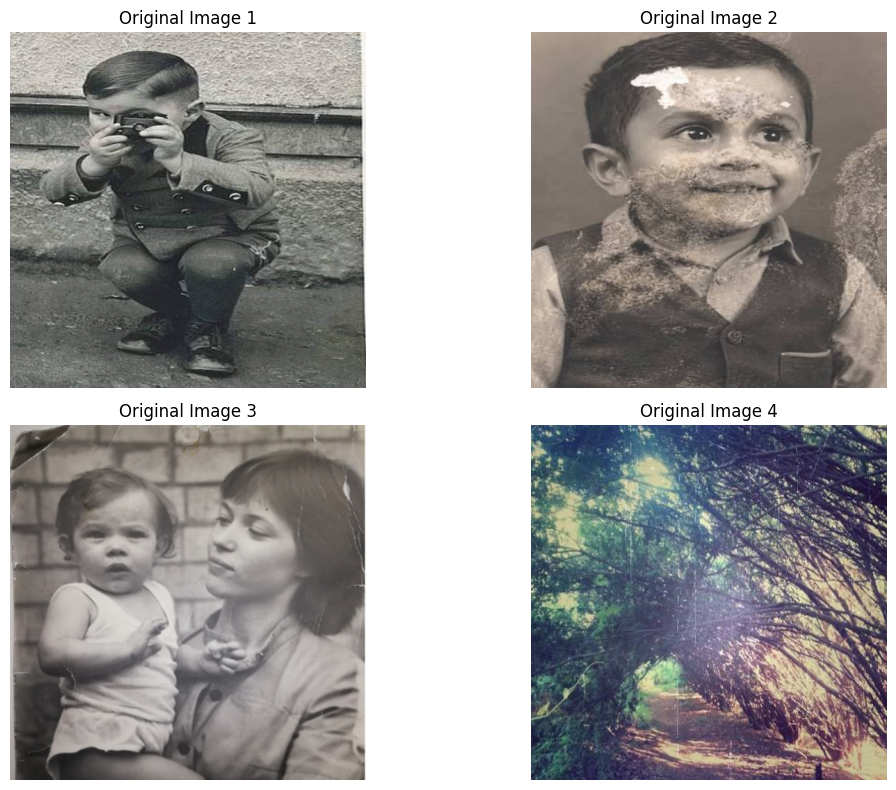

In [4]:
# Display original images

plt.figure(figsize=(12, 8))

for i in range(len(images)):
    plt.subplot(2, 2, i + 1)
    plt.imshow(images[i])
    plt.title("Original Image " + str(i + 1))
    plt.axis("off")

plt.tight_layout()
plt.show()

## 6. Image Degradation Using Gaussian Noise

Gaussian noise is a type of random noise that can occur during image acquisition and transmission.

To simulate a degraded photograph, Gaussian noise is artificially added to each original image.

The resulting noisy images are then used as input for the restoration techniques.

In [5]:
# Add Gaussian noise to the images

noisy_images = []

for img in images:

    noise = np.random.normal(
        0,
        25,
        img.shape
    )

    noisy = img.astype(np.float32) + noise

    noisy = np.clip(
        noisy,
        0,
        255
    ).astype(np.uint8)

    noisy_images.append(noisy)

print("Gaussian noise added successfully!")

Gaussian noise added successfully!


## 7. Original vs Degraded Images

The following comparison shows the difference between the original images and the images after Gaussian noise has been added.

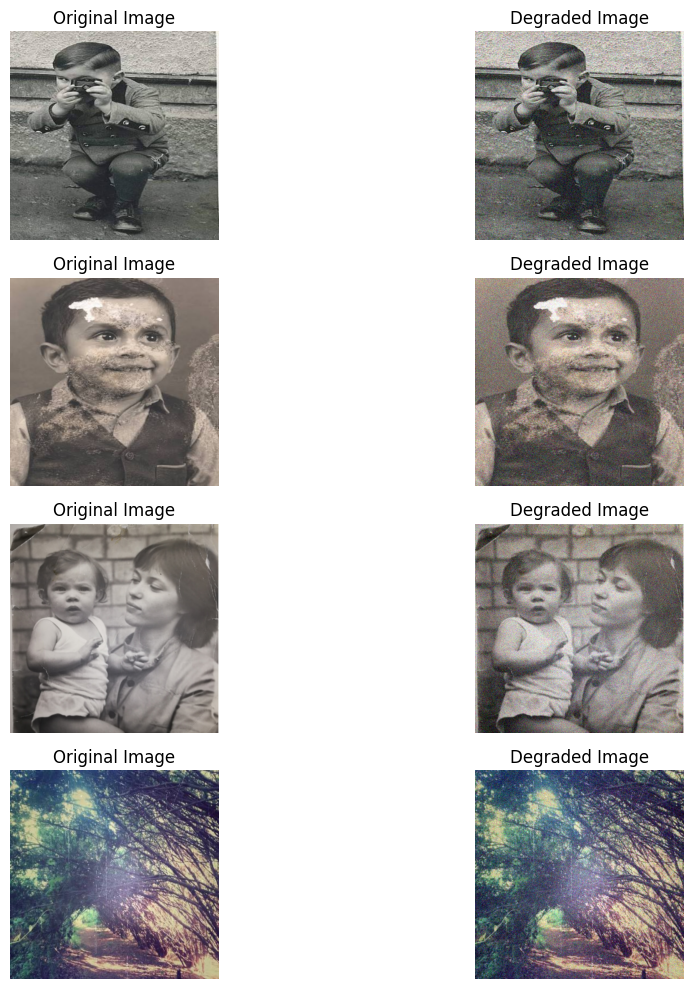

In [6]:
# Display original and degraded images

plt.figure(figsize=(12, 10))

for i in range(4):

    plt.subplot(4, 2, 2*i + 1)
    plt.imshow(images[i])
    plt.title("Original Image")
    plt.axis("off")

    plt.subplot(4, 2, 2*i + 2)
    plt.imshow(noisy_images[i])
    plt.title("Degraded Image")
    plt.axis("off")

plt.tight_layout()
plt.show()

## 8. Restoration Using Median Filtering

Median filtering is a spatial filtering technique used for noise reduction.

It replaces each pixel with the median value of the pixels in its neighbourhood. It is particularly useful for reducing impulse-type noise while preserving important edges.

A 5 × 5 median filter is applied to the degraded images.

In [7]:
# Apply Median Filtering

median_images = []

for img in noisy_images:

    restored = cv2.medianBlur(
        img,
        5
    )

    median_images.append(restored)

print("Median filtering completed!")

Median filtering completed!


## 9. Restoration Using Gaussian Filtering

Gaussian filtering is another spatial smoothing technique.

It reduces image noise by applying a Gaussian-weighted average to neighbouring pixels. A 5 × 5 Gaussian filter is applied to the degraded images.

In [8]:
# Apply Gaussian Filtering

gaussian_images = []

for img in noisy_images:

    restored = cv2.GaussianBlur(
        img,
        (5, 5),
        0
    )

    gaussian_images.append(restored)

print("Gaussian filtering completed!")

Gaussian filtering completed!


## 10. Contrast Enhancement

After noise reduction, contrast enhancement is applied to improve the visibility of image details.

CLAHE (Contrast Limited Adaptive Histogram Equalization) is used because it improves local contrast while limiting excessive enhancement.

In [9]:
# Apply CLAHE contrast enhancement

enhanced_images = []

for img in median_images:

    lab = cv2.cvtColor(
        img,
        cv2.COLOR_RGB2LAB
    )

    l, a, b = cv2.split(lab)

    clahe = cv2.createCLAHE(
        clipLimit=2.0,
        tileGridSize=(8, 8)
    )

    l = clahe.apply(l)

    enhanced = cv2.merge((l, a, b))

    enhanced = cv2.cvtColor(
        enhanced,
        cv2.COLOR_LAB2RGB
    )

    enhanced_images.append(enhanced)

print("Contrast enhancement completed!")

Contrast enhancement completed!


## 11. Comparison of Restoration Techniques

The original image, degraded image, Median Filter result, Gaussian Filter result, and enhanced restoration result are compared visually.

This comparison helps identify how each technique affects image quality.

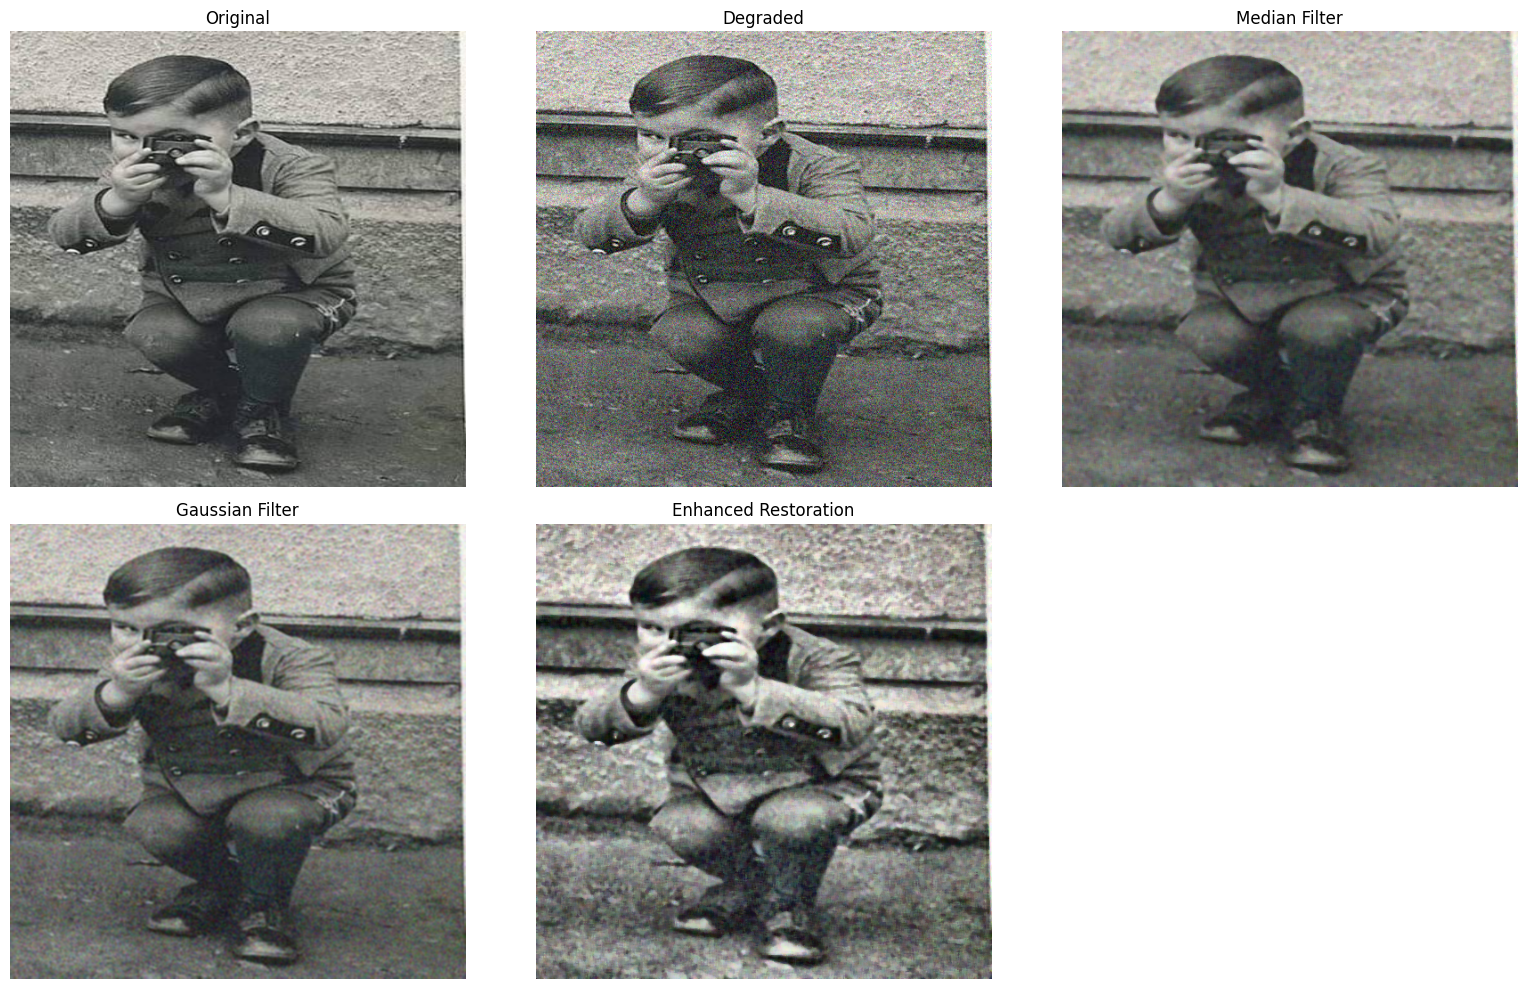

In [10]:
# Compare different restoration results for the first image

i = 0

plt.figure(figsize=(16, 10))

plt.subplot(2, 3, 1)
plt.imshow(images[i])
plt.title("Original")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(noisy_images[i])
plt.title("Degraded")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(median_images[i])
plt.title("Median Filter")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(gaussian_images[i])
plt.title("Gaussian Filter")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(enhanced_images[i])
plt.title("Enhanced Restoration")
plt.axis("off")

plt.tight_layout()
plt.show()

## 12. Quantitative Evaluation

The restoration results are evaluated using three commonly used image quality metrics:

### Mean Squared Error (MSE)
MSE measures the average squared difference between the original and restored images. Lower values indicate smaller error.

### Peak Signal-to-Noise Ratio (PSNR)
PSNR measures the quality of reconstruction. Higher PSNR values generally indicate better restoration.

### Structural Similarity Index (SSIM)
SSIM measures the structural similarity between the original and restored images. Values closer to 1 indicate greater structural similarity.

In [11]:
# Functions for evaluation

def calculate_mse(original, restored):
    return np.mean(
        (original.astype(float) - restored.astype(float)) ** 2
    )


def calculate_psnr(original, restored):

    mse = calculate_mse(
        original,
        restored
    )

    if mse == 0:
        return float("inf")

    return 10 * np.log10(
        (255 ** 2) / mse
    )


def calculate_ssim(original, restored):

    original_gray = cv2.cvtColor(
        original,
        cv2.COLOR_RGB2GRAY
    )

    restored_gray = cv2.cvtColor(
        restored,
        cv2.COLOR_RGB2GRAY
    )

    return ssim(
        original_gray,
        restored_gray,
        data_range=255
    )

In [15]:
import pandas as pd

# Calculate evaluation metrics for all 4 images

results = []

for i in range(4):

    results.append({
        "Image": "Image " + str(i + 1),
        "Degraded MSE": calculate_mse(
            images[i],
            noisy_images[i]
        ),
        "Median MSE": calculate_mse(
            images[i],
            median_images[i]
        ),
        "Gaussian MSE": calculate_mse(
            images[i],
            gaussian_images[i]
        ),
        "Enhanced MSE": calculate_mse(
            images[i],
            enhanced_images[i]
        ),

        "Degraded PSNR": calculate_psnr(
            images[i],
            noisy_images[i]
        ),
        "Median PSNR": calculate_psnr(
            images[i],
            median_images[i]
        ),
        "Gaussian PSNR": calculate_psnr(
            images[i],
            gaussian_images[i]
        ),
        "Enhanced PSNR": calculate_psnr(
            images[i],
            enhanced_images[i]
        ),

        "Degraded SSIM": calculate_ssim(
            images[i],
            noisy_images[i]
        ),
        "Median SSIM": calculate_ssim(
            images[i],
            median_images[i]
        ),
        "Gaussian SSIM": calculate_ssim(
            images[i],
            gaussian_images[i]
        ),
        "Enhanced SSIM": calculate_ssim(
            images[i],
            enhanced_images[i]
        )
    })

results_df = pd.DataFrame(results)

results_df

,Image,Degraded MSE,Median MSE,Gaussian MSE,Enhanced MSE,Degraded PSNR,Median PSNR,Gaussian PSNR,Enhanced PSNR,Degraded SSIM,Median SSIM,Gaussian SSIM,Enhanced SSIM
0,Image 1,614.768279,156.525194,100.319538,798.869288,20.243689,26.184961,28.116948,19.106046,0.544587,0.671276,0.811750,0.581901
1,Image 2,620.166592,74.979923,61.874102,515.329372,20.205720,29.381354,30.215715,21.009955,0.404329,0.783299,0.831681,0.589129
2,Image 3,620.666004,54.476550,58.284761,639.460911,20.202224,30.768708,30.475253,20.072664,0.383668,0.869011,0.864232,0.649403
3,Image 4,616.540838,263.770664,154.614510,832.847018,20.231185,23.918539,26.238301,18.925151,0.670799,0.676733,0.823111,0.653392


## 13. Average Performance Comparison

To obtain an overall comparison, the average MSE, PSNR, and SSIM values across the four images are calculated for each restoration method.

In [16]:
# Calculate average results

average_results = pd.DataFrame({
    "Method": [
        "Degraded",
        "Median Filter",
        "Gaussian Filter",
        "Enhanced Restoration"
    ],

    "Average MSE": [
        results_df["Degraded MSE"].mean(),
        results_df["Median MSE"].mean(),
        results_df["Gaussian MSE"].mean(),
        results_df["Enhanced MSE"].mean()
    ],

    "Average PSNR": [
        results_df["Degraded PSNR"].mean(),
        results_df["Median PSNR"].mean(),
        results_df["Gaussian PSNR"].mean(),
        results_df["Enhanced PSNR"].mean()
    ],

    "Average SSIM": [
        results_df["Degraded SSIM"].mean(),
        results_df["Median SSIM"].mean(),
        results_df["Gaussian SSIM"].mean(),
        results_df["Enhanced SSIM"].mean()
    ]
})

average_results

,Method,Average MSE,Average PSNR,Average SSIM
0,Degraded,618.035428,20.220705,0.500846
1,Median Filter,137.438083,27.563390,0.750080
2,Gaussian Filter,93.773228,28.761554,0.832694
3,Enhanced Restoration,696.626647,19.778454,0.618456


## 14. Visual Comparison of Evaluation Metrics

The following graphs provide a visual comparison of the restoration techniques based on MSE, PSNR, and SSIM.

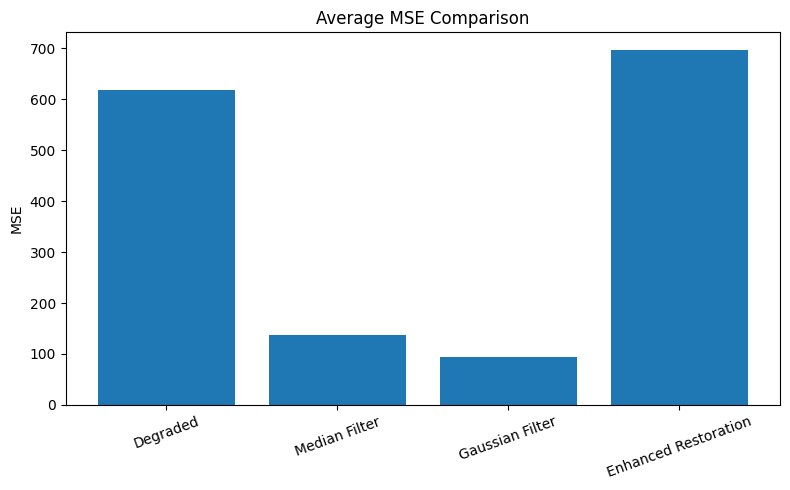

In [17]:
# Plot MSE

plt.figure(figsize=(8, 5))

plt.bar(
    average_results["Method"],
    average_results["Average MSE"]
)

plt.title("Average MSE Comparison")
plt.ylabel("MSE")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

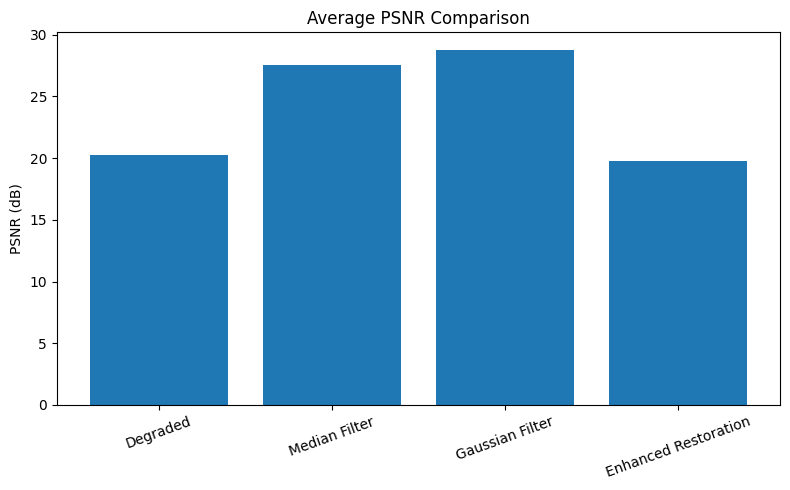

In [18]:
# Plot PSNR

plt.figure(figsize=(8, 5))

plt.bar(
    average_results["Method"],
    average_results["Average PSNR"]
)

plt.title("Average PSNR Comparison")
plt.ylabel("PSNR (dB)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

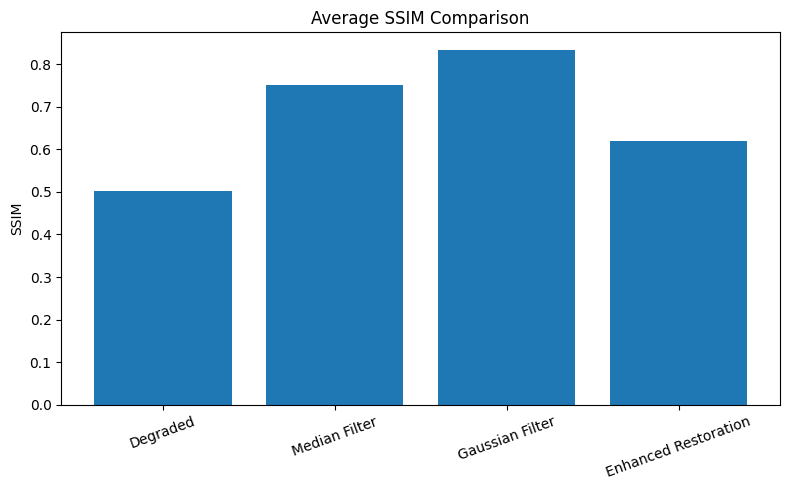

In [19]:
# Plot SSIM

plt.figure(figsize=(8, 5))

plt.bar(
    average_results["Method"],
    average_results["Average SSIM"]
)

plt.title("Average SSIM Comparison")
plt.ylabel("SSIM")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 15. Results and Discussion

The results show the effect of different restoration techniques on degraded images.

The degraded images show visible quality reduction after the addition of Gaussian noise. Median filtering reduces noise while preserving important image structures. Gaussian filtering also smooths the noisy images, although excessive smoothing may remove some fine details.

The contrast enhancement stage improves the visibility of details in the restored images.

The MSE, PSNR, and SSIM values provide quantitative evidence for comparing the restoration methods. A lower MSE indicates lower reconstruction error, while higher PSNR and SSIM values indicate better similarity with the original image.

The performance may vary between images depending on their texture, brightness, edges, and amount of detail.

## 16. Limitations

The project has some limitations:

- Only four images were used for experimentation.
- Gaussian noise was artificially added rather than obtained from real historical photographs.
- The restoration performance depends on the noise level and image characteristics.
- Filtering may remove some fine image details along with noise.
- The selected techniques may not perform equally well for all types of image degradation.

## 17. Future Scope

The project can be improved in the future by:

- Using a larger and more diverse collection of real degraded photographs.
- Testing additional noise models such as salt-and-pepper and speckle noise.
- Applying advanced restoration and deblurring techniques.
- Using deep learning-based image restoration methods.
- Developing a real-time or web-based image restoration application.
- Evaluating the system using a larger dataset and additional image-quality metrics.

## 18. Conclusion

This project demonstrated the use of Digital Image Processing techniques for restoring degraded images. Four reference images were artificially degraded using Gaussian noise and then processed using Median Filtering, Gaussian Filtering, and contrast enhancement.

The restoration techniques were compared visually and quantitatively using MSE, PSNR, and SSIM. The experiment demonstrated how spatial filtering can reduce image degradation and how contrast enhancement can improve the visual quality of restored images.

The project also demonstrated that the effectiveness of a restoration technique depends on the characteristics of the input image and the type and amount of degradation present.